# 01 · Feature selection: FFS grids, frequencies, probes, consensus

The FFS stage per backbone: validation grids over ({psi}, K), selection frequency profiles at the winner cells, the noise-floor diagnostics, a continuous tau-sensitivity analysis derived purely from recorded counts, and the cross-backbone consensus of the final RFFS sets.

### Setup

In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import to_rgb

from _shared import (
    BACKBONES,
    BACKBONE_COLORS,
    BACKBONE_LABELS,
    CATEGORY_COLORS,
    DOUBLE_COL,
    N,
    ONE_HALF_COL,
    OPERATORS,
    OPERATOR_LABELS,
    PROBE_COLOR,
    feature_category,
    init_notebook,
    jload,
    run_dir,
)

FIG_DIR, savefig = init_notebook("01_feature_selection")

campaign: dce-full-rffs-4backbones-xgb-analyses-v2-2026-08-11
figures -> /Users/berthier/Development/PhD/xopa/results/notebook-figures/01_feature_selection


In [2]:
grids = {
    b: {
        op: pd.read_csv(run_dir(b, "rffs") / f"grid_eval_{op}.csv", index_col=0)
        for op in OPERATORS
    }
    for b in BACKBONES
}
freqs = {
    b: pd.read_csv(run_dir(b, "rffs") / "selection_frequency.csv") for b in BACKBONES
}
summaries = {b: jload(run_dir(b, "rffs") / "rffs_summary.json") for b in BACKBONES}
Q = int(freqs["xgboost"]["Q"].iloc[0])
GRID = sorted(grids["xgboost"]["rfe"].index, reverse=True)
print(f"Q={Q}, grid={GRID}")

Q=10, grid=[170, 150, 130, 110, 90, 70, 50, 30]


## Validation grid: operator x $K$, one panel per backbone

Cell colour is validation MSE, annotation is $d_*$ (survivors at $\tau=0.8$).  
The boxed cell is the selected winner.

saved: /Users/berthier/Development/PhD/xopa/results/notebook-figures/01_feature_selection/grid_val_mse_all_backbones.pdf/.png


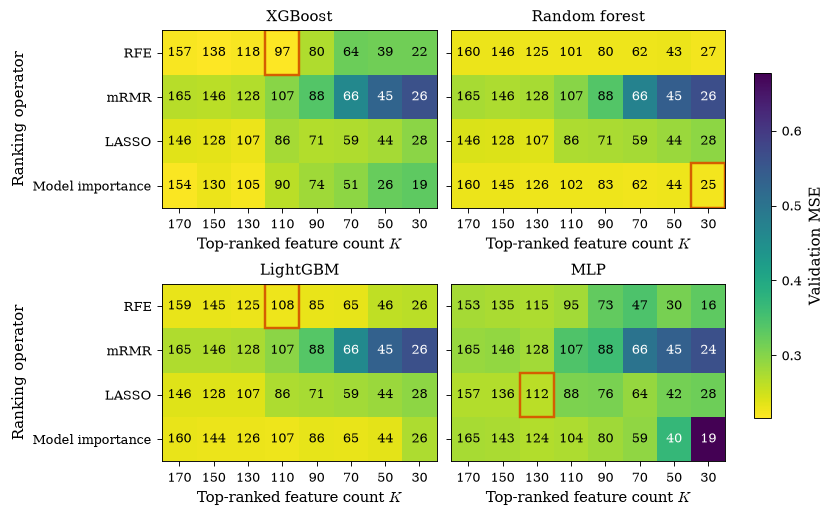

In [3]:
for backbone in BACKBONES:
    for operator in OPERATORS:
        grid = grids[backbone][operator]
        missing_columns = {"val_mse", "d_star"} - set(grid.columns)
        if missing_columns:
            raise ValueError(f"{backbone}/{operator} grid is missing columns: {sorted(missing_columns)}")
        if not np.isfinite(grid["val_mse"]).all() or (grid["val_mse"] < 0).any():
            raise ValueError(f"{backbone}/{operator} validation MSE values must be finite and non-negative")

# Full text width in the manuscript; sharey keeps the operator names on the left
# column while every panel carries its own K ticks and label.
GRID_LABEL_PT, GRID_TICK_PT = 9.5, 8.5
fig, axes = plt.subplots(2, 2, figsize=(DOUBLE_COL, 4.6), sharey=True)
vmin = min(g[op]["val_mse"].min() for g in grids.values() for op in OPERATORS)
vmax = max(g[op]["val_mse"].max() for g in grids.values() for op in OPERATORS)
for ax, backbone in zip(axes.ravel(), BACKBONES):
    matrix = np.array([[grids[backbone][op].loc[k, "val_mse"] for k in GRID] for op in OPERATORS])
    im = ax.imshow(matrix, cmap="viridis_r", vmin=vmin, vmax=vmax, aspect="auto")
    for i, op in enumerate(OPERATORS):
        for j, k in enumerate(GRID):
            d_star = int(grids[backbone][op].loc[k, "d_star"])
            red, green, blue, _ = im.cmap(im.norm(matrix[i, j]))
            luminance = 0.2126 * red + 0.7152 * green + 0.0722 * blue
            text_color = "black" if luminance > 0.6 else "white"
            ax.text(j, i, f"{d_star}", ha="center", va="center", fontsize=GRID_TICK_PT, color=text_color)
    winner = summaries[backbone]["winner"]
    ax.add_patch(
        plt.Rectangle(
            (GRID.index(winner["K"]) - 0.5, OPERATORS.index(winner["operator"]) - 0.5),
            1, 1, fill=False, edgecolor="#D55E00", lw=1.6,
        )
    )
    ax.set_title(BACKBONE_LABELS[backbone], fontsize=GRID_LABEL_PT)
    ax.set_xticks(range(len(GRID)), GRID, fontsize=GRID_TICK_PT)
    ax.set_yticks(range(len(OPERATORS)), [OPERATOR_LABELS[o] for o in OPERATORS], fontsize=GRID_TICK_PT)
    ax.set_xlabel(f"Top-ranked feature count {N['K']}", fontsize=GRID_LABEL_PT)
for ax in axes[:, 0]:
    ax.set_ylabel("Ranking operator", fontsize=GRID_LABEL_PT)
cbar = fig.colorbar(im, ax=axes, shrink=0.8)
cbar.set_label("Validation MSE", fontsize=GRID_LABEL_PT)
cbar.ax.tick_params(labelsize=GRID_TICK_PT)
savefig(fig, "grid_val_mse_all_backbones")
plt.show()

## Selection frequency $\pi_j$ at each winner cell

One panel per backbone, each spanning only the features that were selected at least once at its winner cell.  
Bars are coloured by category, and features clearing $\tau=0.8$ (the survivors, left of the $d_*$ cut) are solid, the rest faded.  
Dotted line: the probe floor, the best selection frequency any synthetic noise column achieved in that cell. A feature below it is selected no more often than known noise.

saved: /Users/berthier/Development/PhD/xopa/results/notebook-figures/01_feature_selection/frequency_profiles_winner_cells.pdf/.png


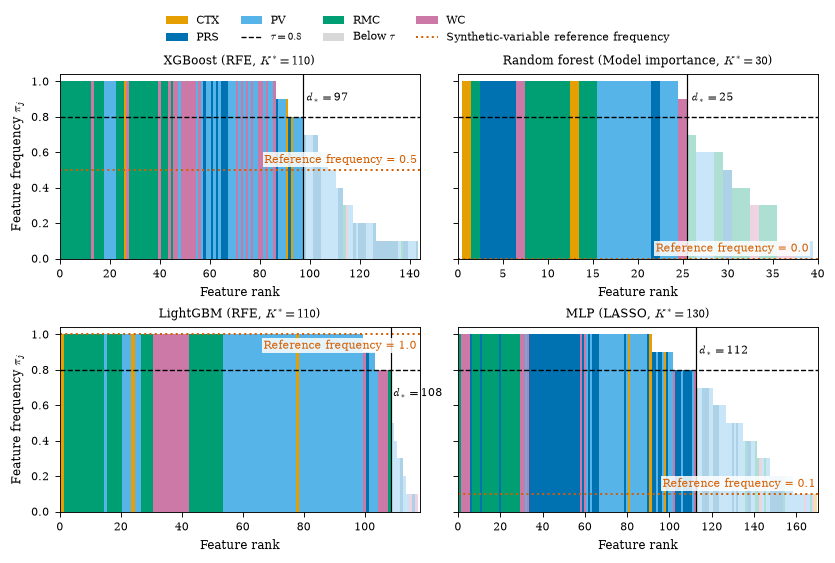

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(DOUBLE_COL, 4.6), sharey=True)
tau_count = math.ceil(0.8 * Q)
for ax, backbone in zip(axes.ravel(), BACKBONES):
    winner = summaries[backbone]["winner"]
    cell = freqs[backbone].query(
        "operator == @winner['operator'] and K == @winner['K']"
    )
    real = (
        cell[~cell["is_probe"]]
        .query("frequency > 0")
        .sort_values("frequency", ascending=False)
        .reset_index(drop=True)
    )
    probes = cell[cell["is_probe"]]
    n = len(real)
    ranks = np.arange(1, n + 1)
    survives = (real["count"] >= tau_count).to_numpy()
    colors = np.array(
        [CATEGORY_COLORS.get(c, "#999999") for c in real["category"]]
    )
    ax.bar(
        ranks[survives], real.loc[survives, "frequency"], width=1.0,
        color=colors[survives], lw=0,
    )
    ax.bar(
        ranks[~survives], real.loc[~survives, "frequency"], width=1.0,
        color=colors[~survives], alpha=0.32, lw=0,
    )
    d_star = int(survives.sum())
    ax.axhline(0.8, color="black", ls="--", lw=0.9)
    probe_floor = float(probes["frequency"].max()) if len(probes) else 0.0
    ax.axhline(probe_floor, color=PROBE_COLOR, ls=":", lw=1.3)
    if probe_floor > 0.9:
        floor_y, floor_va, dstar_y = probe_floor - 0.03, "top", 0.70
    else:
        floor_y, floor_va, dstar_y = probe_floor + 0.025, "bottom", 0.94
    ax.text(
        n, floor_y, f"Reference frequency = {probe_floor:.1f}",
        ha="right", va=floor_va, fontsize=7, color=PROBE_COLOR,
        bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.85, "pad": 1.0},
    )
    ax.axvline(d_star + 0.5, color="black", lw=0.8)
    ax.text(
        d_star + max(1.0, 0.012 * n), dstar_y, f"{N['d_star']}$=${d_star}",
        ha="left", va="top", fontsize=7.5,
    )
    ax.set_title(
        f"{BACKBONE_LABELS[backbone]} ({OPERATOR_LABELS[winner['operator']]}, "
        f"$K^{{*}}={winner['K']}$)"
    )
    ax.set_xlabel("Feature rank")
    ax.set_ylim(0, 1.04)
    ax.set_xlim(0, n + 1)
axes[0, 0].set_ylabel(f"Feature frequency {N['pi_j']}")
axes[1, 0].set_ylabel(f"Feature frequency {N['pi_j']}")
handles = [
    plt.Rectangle((0, 0), 1, 1, fc=c, label=cat)
    for cat, c in CATEGORY_COLORS.items()
]
handles += [
    plt.Line2D([], [], color="black", ls="--", lw=0.9, label=N["tau"] + "$=0.8$"),
    plt.Rectangle((0, 0), 1, 1, fc="#888888", alpha=0.32, label="Below " + N["tau"]),
    plt.Line2D([], [], color=PROBE_COLOR, ls=":", lw=1.3, label="Synthetic-variable reference frequency"),
]
# matplotlib fills legends column by column: interleave so that the legend reads row by row
handles = [h for pair in zip(handles[:4], handles[4:]) for h in pair]
fig.legend(handles=handles, ncol=4, loc="upper center", bbox_to_anchor=(0.5, 1.09))
savefig(fig, "frequency_profiles_winner_cells")
plt.show()

## $\tau$-sensitivity, derived post hoc from the recorded counts

How much does the asserted threshold matter?  
Sweeping $\tau$ over the recorded selection counts gives, at each winner cell: 
- left, the survivor count $d_*(\tau)$, a step function since only $\lceil \tau Q \rceil$ matters 
- right, the Jaccard overlap between the $\tau$-survivor set and the paper's $\tau=0.8$ set, where a wide plateau inside the shaded band means the selection barely changes with the threshold.  

Circles mark the data-determined $\tau_{auto}$ (one level above the worst probe frequency).  
LightGBM has none: its probes reached frequency 1.0, so no admissible automatic threshold exists and that cell is noise-indistinguishable under the automatic rule.  
Legend entries carry each backbone's $d_*$ at $\tau=0.8$.

saved: /Users/berthier/Development/PhD/xopa/results/notebook-figures/01_feature_selection/tau_sensitivity_winner_cells.pdf/.png


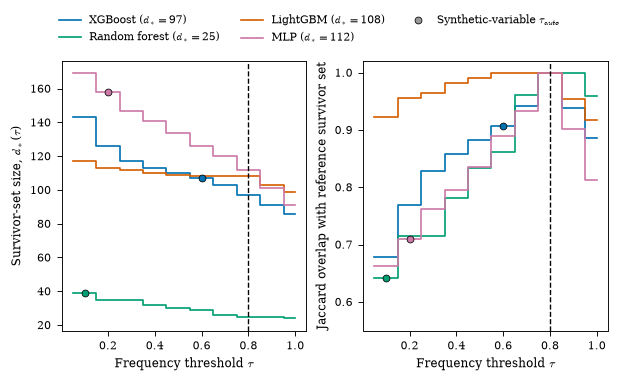

,reference frequency,tau_auto,survivors at tau_auto,Jaccard vs tau=0.8
backbone,,,,
XGBoost,0.5,0.6,107.0,0.906542
Random forest,0.0,0.1,39.0,0.641026
LightGBM,1.0,NaN,NaN,NaN
MLP,0.1,0.2,158.0,0.708861


In [5]:
tau_grid = np.round(np.arange(0.05, 1.001, 0.05), 2)
tau_summary_rows = []
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(ONE_HALF_COL, 2.9), sharex=True)
for backbone in BACKBONES:
    winner = summaries[backbone]["winner"]
    cell = freqs[backbone].query(
        "operator == @winner['operator'] and K == @winner['K']"
    )
    real = cell[~cell["is_probe"]]
    probes = cell[cell["is_probe"]]
    base = set(real.loc[real["count"] >= math.ceil(0.8 * Q), "feature"])
    d_curve, j_curve = [], []
    for tau in tau_grid:
        kept = set(real.loc[real["count"] >= math.ceil(tau * Q), "feature"])
        d_curve.append(len(kept))
        j_curve.append(len(kept & base) / len(kept | base) if kept | base else 1.0)
    color = BACKBONE_COLORS[backbone]
    label = f"{BACKBONE_LABELS[backbone]} ({N['d_star']}$=${len(base)})"
    ax1.plot(tau_grid, d_curve, color=color, drawstyle="steps-post", label=label)
    ax2.plot(tau_grid, j_curve, color=color, drawstyle="steps-post")
    max_probe = int(probes["count"].max()) if len(probes) else 0
    tau_auto = None
    kept_auto = set()
    j_auto = np.nan
    if max_probe < Q:
        tau_auto = (max_probe + 1) / Q
        kept_auto = set(real.loc[real["count"] >= max_probe + 1, "feature"])
        j_auto = (
            len(kept_auto & base) / len(kept_auto | base) if kept_auto | base else 1.0
        )
        marker_kw = dict(
            marker="o", ms=4.5, mec="black", mew=0.5, color=color, zorder=4
        )
        ax1.plot(tau_auto, len(kept_auto), ls="none", **marker_kw)
        ax2.plot(tau_auto, j_auto, ls="none", **marker_kw)
    tau_summary_rows.append(
        {
            "backbone": BACKBONE_LABELS[backbone],
            "reference frequency": max_probe / Q,
            "tau_auto": tau_auto,
            "survivors at tau_auto": (
                len(kept_auto) if tau_auto is not None else np.nan
            ),
            "Jaccard vs tau=0.8": j_auto,
        }
    )
for ax in (ax1, ax2):
    ax.axvline(0.8, color="black", ls="--", lw=0.9)
    ax.set_xlabel("Frequency threshold " + N["tau"])
ax1.set_ylabel(f"Survivor-set size, {N['d_star']}({N['tau']})")
ax2.set_ylabel("Jaccard overlap with reference survivor set")
ax2.set_ylim(0.55, 1.02)
handles, labels = ax1.get_legend_handles_labels()
handles.append(
    plt.Line2D(
        [], [], marker="o", ms=4.5, mec="black", mew=0.5, color="#999999",
        ls="none", label="Synthetic-variable " + N["tau"] + "$_{auto}$",
    )
)
fig.legend(handles=handles, ncol=3, loc="upper center", bbox_to_anchor=(0.5, 1.16))
savefig(fig, "tau_sensitivity_winner_cells")
plt.show()
tau_sensitivity_summary = pd.DataFrame(tau_summary_rows).set_index("backbone")
tau_sensitivity_summary

## Cross-backbone consensus of the final RFFS sets

Which features does every learner agree on?  
Each column is one of the features selected by at least one backbone, each row a backbone, and a filled cell (in the feature's category colour) means membership in that backbone's refined set $d_+$.  
Columns are grouped by how many backbones agree, from the unanimous core on the left to the singletons on the right, with the orange line closing the core.  
Row labels carry each backbone's $d_+$.

union size: 69; in all four backbones (12): ['data_002', 'data_064', 'data_085', 'data_103', 'data_106', 'data_108', 'data_113', 'data_118', 'data_129', 'data_136', 'data_137', 'data_151']
saved: /Users/berthier/Development/PhD/xopa/results/notebook-figures/01_feature_selection/consensus_membership.pdf/.png


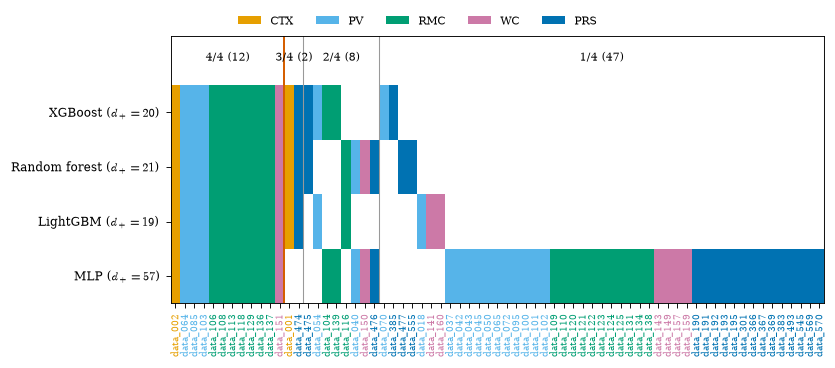

In [6]:
finals = {b: summaries[b]["final_features"] for b in BACKBONES}
union = sorted(set().union(*finals.values()))
membership = pd.DataFrame(
    {b: [f in finals[b] for f in union] for b in BACKBONES}, index=union
)
membership["n"] = membership.sum(axis=1)
membership = membership.sort_values(["n"] + BACKBONES, ascending=False)
core = membership.index[membership["n"] == 4].tolist()
print(f"union size: {len(union)}; in all four backbones ({len(core)}): {core}")

image = np.ones((len(BACKBONES), len(membership), 3))
for j, feature in enumerate(membership.index):
    rgb = to_rgb(CATEGORY_COLORS.get(feature_category(feature), "#999999"))
    for i, backbone in enumerate(BACKBONES):
        if membership.loc[feature, backbone]:
            image[i, j] = rgb

fig, ax = plt.subplots(figsize=(DOUBLE_COL, 3.0))
ax.imshow(image, aspect="auto", interpolation="nearest")
ax.set_yticks(
    range(4),
    [rf"{BACKBONE_LABELS[b]} ($d_+={len(finals[b])}$)" for b in BACKBONES],
    fontsize=8,
)
ax.set_xticks(range(len(membership)), membership.index, rotation=90, fontsize=6.2)
for tick, feature in zip(ax.get_xticklabels(), membership.index):
    tick.set_color(CATEGORY_COLORS.get(feature_category(feature), "#999999"))
group_sizes = membership["n"].value_counts().sort_index(ascending=False)
edge = -0.5
for n_agree, size in group_sizes.items():
    edge += size
    ax.axvline(
        edge, color="#D55E00" if n_agree == 4 else "#999999",
        lw=1.3 if n_agree == 4 else 0.7,
    )
    ax.text(
        edge - size / 2, -0.9, f"{n_agree}/4 ({size})",
        ha="center", va="bottom", fontsize=7.5,
    )
ax.set_ylim(3.5, -1.4)
category_handles = [
    plt.Rectangle((0, 0), 1, 1, fc=c, label=cat) for cat, c in CATEGORY_COLORS.items()
]
fig.legend(
    handles=category_handles, ncol=5, loc="upper center",
    bbox_to_anchor=(0.5, 1.08), fontsize=7.5,
)
savefig(fig, "consensus_membership")
plt.show()

## Category composition: selection counts versus attribution credit

Where do the selected features come from, and where does the explanatory credit go?  
Both panels are 100-percent compositions over the five categories.  
Left: the share of selected features per backbone, with the 316-candidate pool as the reference bar, so departures from the pool are enrichment or depletion; segment labels give the actual counts.  
Right: the share of total mean $|$SHAP$|$ ($I_j$) carried by each category in the refined set, computed over the full dataset.  
Comparing a backbone's two bars separates how many features a category contributes from how much credit those features receive.

,d_plus,explained_records,recorded_test_r2,explain_refit_test_r2,delta_r2
backbone,,,,,
XGBoost,20,35125,0.7729,0.7729,0.0000
Random forest,21,35125,0.7642,0.7639,-0.0003
LightGBM,19,35125,0.7642,0.7642,0.0000
MLP,57,35125,0.7649,0.7614,-0.0035


saved: /Users/berthier/Development/PhD/xopa/results/notebook-figures/01_feature_selection/category_composition.pdf/.png


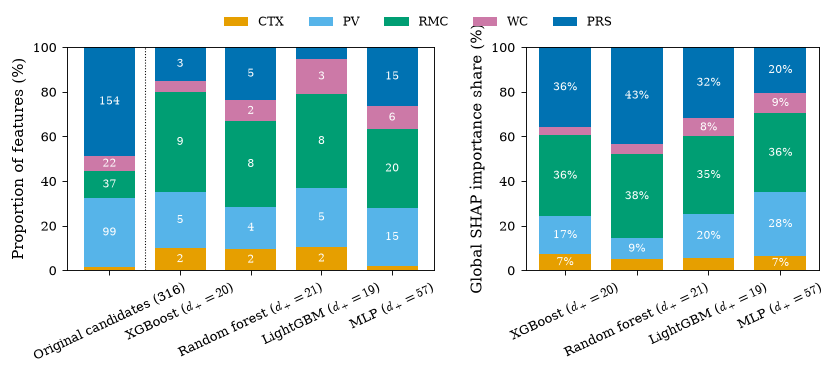

In [7]:
pool_counts = pd.Series(
    [feature_category(f) for f in freqs["xgboost"]["feature"].unique()
     if not f.startswith("__probe_")]
).value_counts().reindex(CATEGORY_COLORS).fillna(0).astype(int)
backbone_axis_label = {b: rf"{BACKBONE_LABELS[b]} ($d_+={len(finals[b])}$)" for b in BACKBONES}
counts = pd.DataFrame(
    {
        backbone_axis_label[b]: pd.Series(
            [feature_category(f) for f in finals[b]]
        ).value_counts()
        for b in BACKBONES
    }
).reindex(CATEGORY_COLORS).fillna(0).astype(int)
counts.insert(0, f"Original candidates ({pool_counts.sum()})", pool_counts)
count_pct = 100 * counts / counts.sum()
full_data_shares = {}
provenance_rows = []
expected_records = None
for backbone in BACKBONES:
    rffs_dir = run_dir(backbone, "rffs")
    explain_dir = run_dir(backbone, "explain")
    rffs_assignments = pd.read_csv(
        rffs_dir / "split_assignments.csv"
    ).sort_values("row_id").reset_index(drop=True)
    explain_assignments = pd.read_csv(
        explain_dir / "split_assignments.csv"
    ).sort_values("row_id").reset_index(drop=True)
    if not rffs_assignments.equals(explain_assignments):
        raise ValueError(f"{backbone}: explanation split differs from RFFS")
    rffs_manifest = jload(rffs_dir / "manifest.json")
    manifest = jload(explain_dir / "manifest.json")
    if manifest["config"]["models"][backbone] != rffs_manifest["config"]["models"][backbone]:
        raise ValueError(f"{backbone}: model configuration differs from RFFS")
    rffs_identity = jload(rffs_dir / "dataset_identity.json")
    identity = jload(explain_dir / "dataset_identity.json")
    if identity["sha256"] != rffs_identity["sha256"]:
        raise ValueError(f"{backbone}: dataset identity differs from RFFS")
    bundle = np.load(explain_dir / "shap_bundle.npz", allow_pickle=True)
    row_count = len(bundle["row_ids"])
    explained_features = [str(f) for f in bundle["feature_names"]]
    if manifest.get("stage") != "explain":
        raise ValueError(f"{backbone}: expected an explain-stage artifact")
    if row_count != manifest.get("n_records"):
        raise ValueError(f"{backbone}: SHAP rows do not match the manifest")
    if row_count != identity["cleaned_shape"][0]:
        raise ValueError(f"{backbone}: SHAP values do not cover the full dataset")
    if len(np.unique(bundle["row_ids"])) != row_count:
        raise ValueError(f"{backbone}: duplicate record identifiers in SHAP bundle")
    if manifest.get("n_features") != len(finals[backbone]):
        raise ValueError(f"{backbone}: explained dimension does not match d_plus")
    if expected_records is None:
        expected_records = row_count
    elif row_count != expected_records:
        raise ValueError(f"{backbone}: explanations do not cover the same records")
    if explained_features != finals[backbone]:
        raise ValueError(f"{backbone}: explained variables do not match d_plus")
    category_share = pd.read_csv(
        explain_dir / "category_summary.csv", index_col=0
    )["share_abs_shap"].reindex(CATEGORY_COLORS)
    if not np.isclose(category_share.sum(), 1.0):
        raise ValueError(f"{backbone}: category shares do not sum to one")
    full_data_shares[backbone_axis_label[backbone]] = category_share
    recorded_test_r2 = summaries[backbone]["test_metrics"][
        f"rffs_d_plus_{summaries[backbone]['d_plus']}"
    ]["r2"]
    explain_test_r2 = jload(explain_dir / "model_test_metrics.json")["r2"]
    provenance_rows.append(
        {
            "backbone": BACKBONE_LABELS[backbone],
            "d_plus": len(finals[backbone]),
            "explained_records": row_count,
            "recorded_test_r2": recorded_test_r2,
            "explain_refit_test_r2": explain_test_r2,
            "delta_r2": explain_test_r2 - recorded_test_r2,
        }
    )
display(pd.DataFrame(provenance_rows).set_index("backbone").round(4))
shares = pd.DataFrame(full_data_shares)
share_pct = 100 * shares

fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(DOUBLE_COL, 3.0),
    gridspec_kw={"width_ratios": [1.25, 1], "wspace": 0.08},
)
for ax, table, annotate in ((ax1, count_pct, counts), (ax2, share_pct, None)):
    bottom = np.zeros(table.shape[1])
    for category in CATEGORY_COLORS:
        values = table.loc[category].to_numpy()
        ax.bar(
            table.columns, values, bottom=bottom, width=0.72,
            color=CATEGORY_COLORS[category], label=category,
        )
        for x, (value, base) in enumerate(zip(values, bottom)):
            if value >= 6:
                text = (
                    str(int(annotate.loc[category].iloc[x]))
                    if annotate is not None
                    else f"{value:.0f}%"
                )
                ax.text(
                    x, base + value / 2, text, ha="center", va="center",
                    fontsize=7.5, color="white",
                )
        bottom += values
    ax.tick_params(axis="x", rotation=25, labelsize=8.5)
    ax.tick_params(axis="y", labelsize=8.5)
    ax.set_ylim(0, 100)
ax1.set_ylabel("Proportion of features (%)", fontsize=9.5)
ax2.set_ylabel("Global SHAP importance share (%)", fontsize=9.5)
ax1.axvline(0.5, color="black", lw=0.7, ls=":")
handles, labels = ax1.get_legend_handles_labels()
fig.legend(
    handles, labels, ncol=5, loc="upper center",
    bbox_to_anchor=(0.5, 1.1), fontsize=8,
)
savefig(fig, "category_composition")
plt.show()